[*********************100%***********************]  1 of 1 completed
/root/cryptobot-enviroment/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/root/cryptobot-enviroment/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/root/cryptobot-enviroment/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Results for xrp-USD:
- Hurst Exponent: 0.8175
- Lyapunov Exponent: Not Calculated
- Volatility: nan


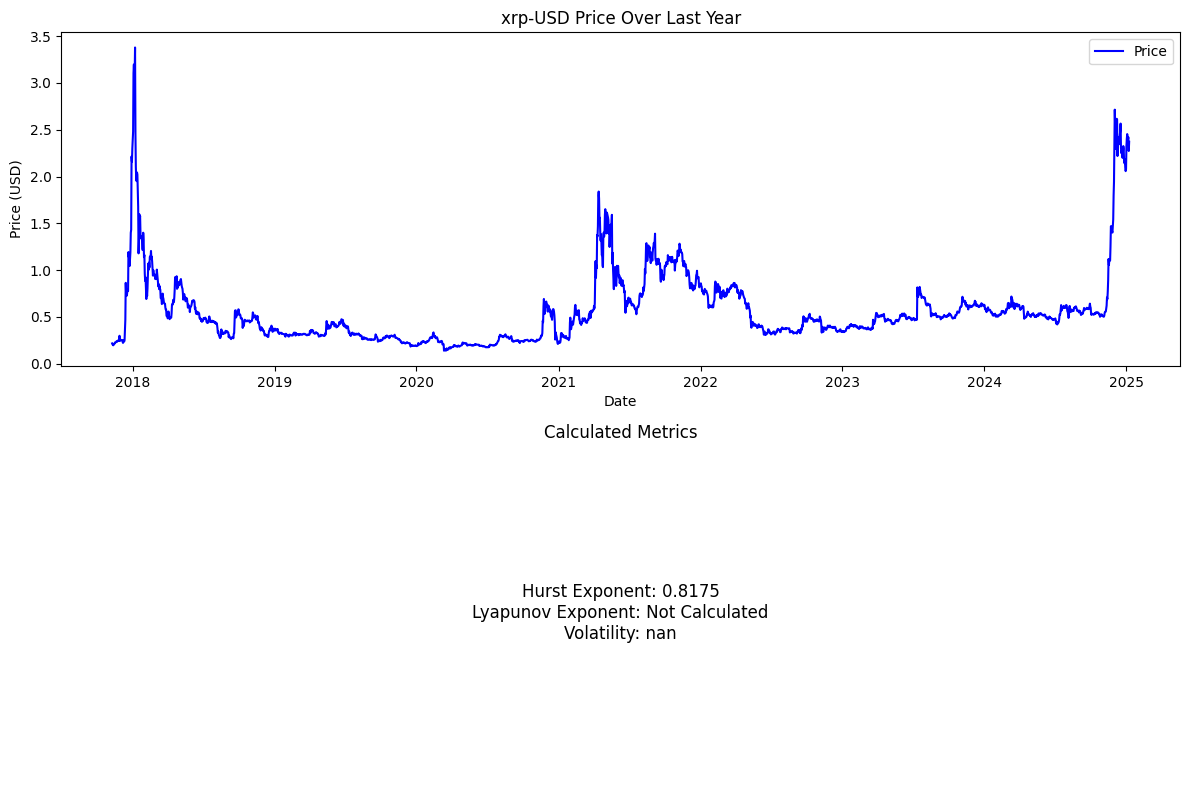

In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from numpy.linalg import norm

# Helper functions
def hurst_exponent(ts):
    n = len(ts)
    ts_cumsum = np.cumsum(ts - np.mean(ts))
    R = np.max(ts_cumsum) - np.min(ts_cumsum)
    S = np.std(ts)
    H = np.log(R / S) / np.log(n)
    return H

def lyapunov_exponent(ts, embedding_dim=2, time_delay=1):
    ts_diff = np.diff(ts)
    if len(ts_diff) < embedding_dim * time_delay:
        return None  # Not enough data points
    N = len(ts_diff)
    eps = 1e-6  # Small epsilon to avoid log(0)
    divergence = []
    for i in range(N - embedding_dim * time_delay):
        vector1 = ts_diff[i:i + embedding_dim * time_delay:time_delay]
        for j in range(i + 1, N - embedding_dim * time_delay):
            vector2 = ts_diff[j:j + embedding_dim * time_delay:time_delay]
            dist = norm(vector1 - vector2)
            if dist > eps:
                divergence.append(np.log(dist))
    if divergence:
        return np.mean(divergence)
    else:
        return None

# Select a single cryptocurrency
crypto = 'xrp-USD'

# Fetch data for the selected cryptocurrency
crypto_data = yf.download(crypto, period="max", interval="1d")['Close'].dropna()

# Remove non-positive values for log calculations
crypto_data = crypto_data[crypto_data > 0]

# Calculate metrics
hurst = hurst_exponent(crypto_data.values)
volatility = np.std(np.diff(np.log(crypto_data))) if len(crypto_data) > 1 else None
lyapunov = lyapunov_exponent(crypto_data.values)

# Handle NoneType results
volatility_str = f"{volatility:.4f}" if volatility is not None else "Not Calculated"
lyapunov_str = f"{lyapunov:.4f}" if lyapunov is not None else "Not Calculated"

# Display the results
print(f"Results for {crypto}:")
print(f"- Hurst Exponent: {hurst:.4f}")
print(f"- Lyapunov Exponent: {lyapunov_str}")
print(f"- Volatility: {volatility_str}")

# Plot the data and results
plt.figure(figsize=(12, 8))

# Plot the cryptocurrency price data
plt.subplot(2, 1, 1)
plt.plot(crypto_data, label='Price', color='blue')
plt.title(f"{crypto} Price Over Last Year")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()

# Display metrics as text
plt.subplot(2, 1, 2)
plt.axis('off')
metrics_text = (
    f"Hurst Exponent: {hurst:.4f}\n"
    f"Lyapunov Exponent: {lyapunov_str}\n"
    f"Volatility: {volatility_str}"
)
plt.text(0.5, 0.5, metrics_text, fontsize=12, ha='center', va='center')
plt.title("Calculated Metrics")

plt.tight_layout()
plt.show()
